In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import TimeDistributed

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

2025-02-10 21:39:33.550330: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-10 21:39:33.609015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-10 21:39:33.649526: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-10 21:39:33.661395: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-10 21:39:33.679546: I tensorflow/core/platform/cpu_feature_guar

In [2]:
image_path = 'archive/Images' 

In [3]:
data = pd.read_csv("archive/captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [4]:
def readImage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    
    return img

def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize = (20 , 20))
    n = 0
    for i in range(15):
        n+=1
        plt.subplot(5 , 5, n)
        plt.subplots_adjust(hspace = 0.7, wspace = 0.3)
        image = readImage(f"archive/Images/{temp_df.image[i]}")
        plt.imshow(image)
        plt.title("\n".join(wrap(temp_df.caption[i], 20)))
        plt.axis("off")

# **Visualization**
- Images and their corresponding captions

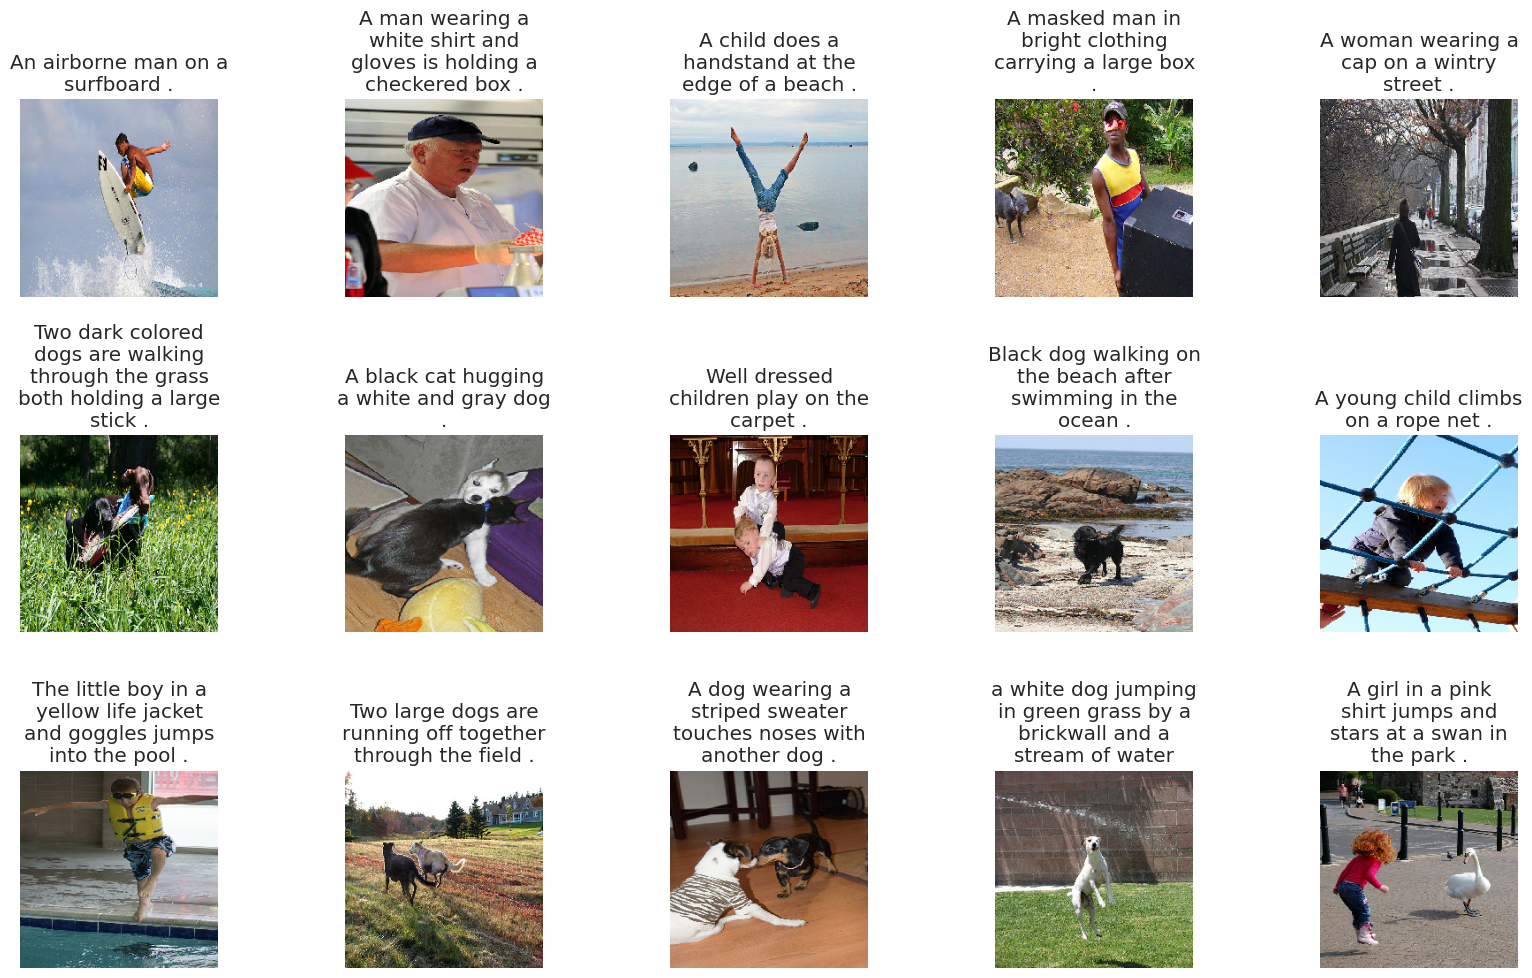

In [5]:
display_images(data.sample(15))

# **Caption Text Preprocessing Steps**
- Convert sentences into lowercase
- Remove special characters and numbers present in the text
- Remove extra spaces
- Remove single characters
- Add a starting and an ending tag to the sentences to indicate the beginning and the ending of a sentence

<img src='http://zjpnrm2br14wspo448nls17u-wpengine.netdna-ssl.com/wp-content/uploads/2020/09/processing-steps.png' >

In [6]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].apply(lambda x: x.replace("[^A-Za-z]",""))
    data['caption'] = data['caption'].apply(lambda x: x.replace("\s+"," "))
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word)>1]))
    data['caption'] = "startseq "+data['caption']+" endseq"
    return data

## __Preprocessed Text__

In [7]:
data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri-colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [8]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[1, 18, 315, 63, 195, 116, 2]

In [9]:
model = DenseNet201()
fe = Model(inputs=model.input, outputs=model.layers[-2].output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img,axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

I0000 00:00:1739216381.843494  380464 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216381.952551  380464 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216381.953699  380464 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216381.955947  380464 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [35]:
class CustomDataGenerator(Sequence):
    
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, 
                 vocab_size, max_length, features,shuffle=True):
    
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return self.n // self.batch_size
    
    def __getitem__(self,index):
    
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)        
        return (X1, X2), y
    
    def __get_data(self, batch):
        X1, X2, y = list(), list(), list()
        
        for _, row in batch.iterrows():
            image = row[self.X_col]
            caption = row[self.y_col]
            feature = self.features[image][0]
            
            seq = self.tokenizer.texts_to_sequences([caption])[0]
            
            in_seq = seq[:-1]
            out_seq = seq[:] 
            in_seq = pad_sequences([in_seq], maxlen=self.max_length, padding='post')[0]
            out_seq = pad_sequences([out_seq], maxlen=self.max_length+1, padding='post')[0]
            
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
            
        return np.array(X1), np.array(X2), np.array(y)

# **Modelling**
- The image embedding representations are concatenated with the first word of sentence ie. starseq and passed to the LSTM network 
- The LSTM network starts generating words after each input thus forming a sentence at the end

<img src='https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png'>

In [36]:
# input1 = Input(shape=(1920,))
# input2 = Input(shape=(max_length,))

# img_features = Dense(256, activation='relu')(input1)
# img_features_reshaped = Reshape((1, 256), input_shape=(256,))(img_features)

# sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
# merged = concatenate([img_features_reshaped,sentence_features],axis=1)
# sentence_features = LSTM(256)(merged)
# x = Dropout(0.5)(sentence_features)
# x = add([x, img_features])
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.5)(x)
# output = Dense(vocab_size, activation='softmax')(x)

# caption_model = Model(inputs=[input1,input2], outputs=output)
# caption_model.compile(loss='categorical_crossentropy',optimizer='adam')

In [37]:
input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256), input_shape=(256,))(img_features)

sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped,sentence_features],axis=1)
lstm_sequence = LSTM(256, return_sequences=True)(merged)  # Shape: (batch, max_length+1, 256)
output = TimeDistributed(Dense(vocab_size, activation='softmax'))(lstm_sequence)  
caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [38]:
from tensorflow.keras.utils import plot_model

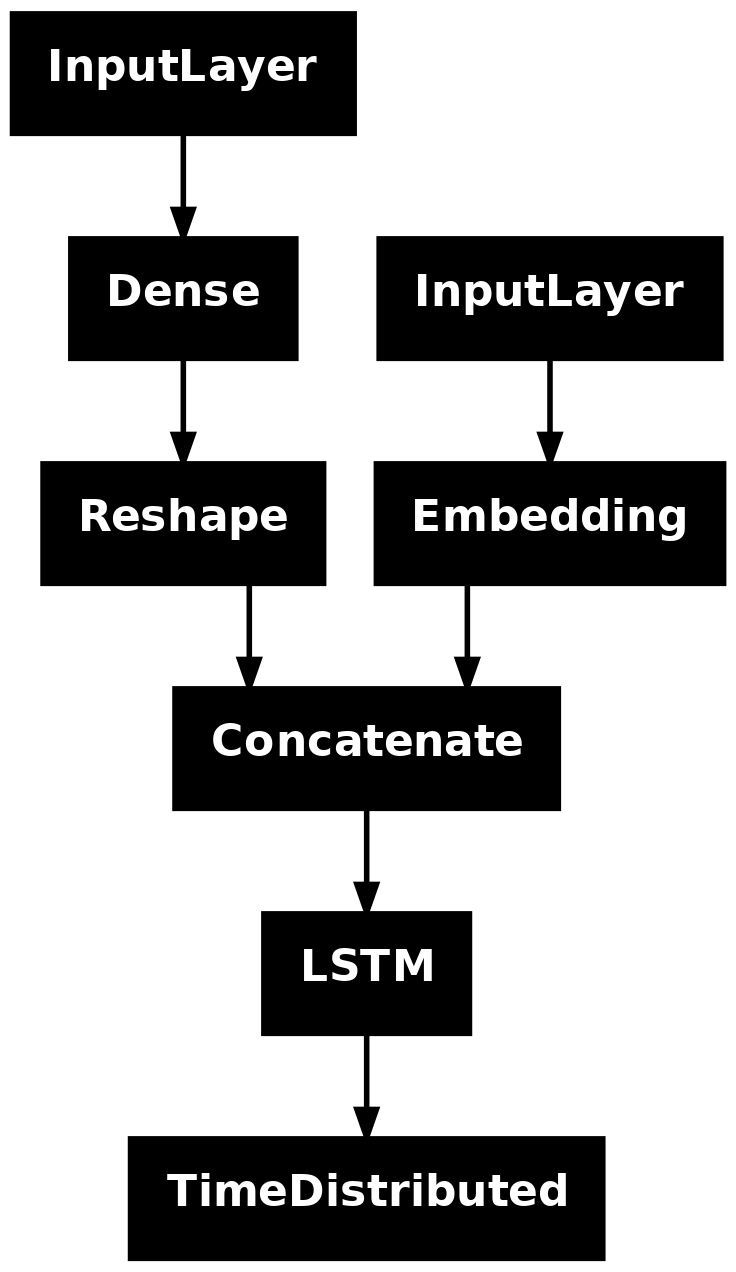

In [39]:
plot_model(caption_model)

In [40]:
caption_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 1920)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    491,776 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 256)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 34, 256)   │  2,172,160 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 35, 256)   │          0 │ reshape_3[0][0],  │
│ (Concatenate)       │                   │            │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 35, 256)   │    525,312 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 35, 8485)  │  2,180,645 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,369,893 (20.48 MB)

 Trainable params: 5,369,893 (20.48 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

In [42]:
model_name = "model_captioning.h5"
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)

earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.2, 
                                            min_lr=0.00000001)

In [43]:
history = caption_model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.4576
Epoch 1: val_loss improved from inf to 1.38911, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - loss: 2.4550 - val_loss: 1.3891 - learning_rate: 0.0010
Epoch 2/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.3364
Epoch 2: val_loss improved from 1.38911 to 1.24226, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - loss: 1.3364 - val_loss: 1.2423 - learning_rate: 0.0010
Epoch 3/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1957
Epoch 3: val_loss improved from 1.24226 to 1.15884, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - loss: 1.1956 - val_loss: 1.1588 - learning_rate: 0.0010
Epoch 4/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.0956
Epoch 4: val_loss improved from 1.15884 to 1.10270, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - loss: 1.0956 - val_loss: 1.1027 - learning_rate: 0.0010
Epoch 5/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.0273
Epoch 5: val_loss improved from 1.10270 to 1.06521, saving model to model_captioning.h5


...

537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - loss: 0.9651 - val_loss: 1.0440 - learning_rate: 0.0010
Epoch 7/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.9140
Epoch 7: val_loss improved from 1.04396 to 1.02699, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - loss: 0.9140 - val_loss: 1.0270 - learning_rate: 0.0010
Epoch 8/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8734
Epoch 8: val_loss improved from 1.02699 to 1.01902, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - loss: 0.8734 - val_loss: 1.0190 - learning_rate: 0.0010
Epoch 9/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8303
Epoch 9: val_loss improved from 1.01902 to 1.01550, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.8303 - val_loss: 1.0155 - learning_rate: 0.0010
Epoch 10/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7980
Epoch 10: val_loss improved from 1.01550 to 1.01343, saving model to model_captioning.h5


537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.7980 - val_loss: 1.0134 - learning_rate: 0.0010
Epoch 11/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7660
Epoch 11: val_loss did not improve from 1.01343
537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.7660 - val_loss: 1.0171 - learning_rate: 0.0010
Epoch 12/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7401
Epoch 12: val_loss did not improve from 1.01343
537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.7402 - val_loss: 1.0182 - learning_rate: 0.0010
Epoch 13/50
536/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7067
Epoch 13: val_loss did not improve from 1.01343

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.7067 - val_loss: 1.0222 - learning_rate: 0.0010
Epoch 14/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.6690
Epoch 14: val_loss did not improve from 1.01343
537/537 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - loss

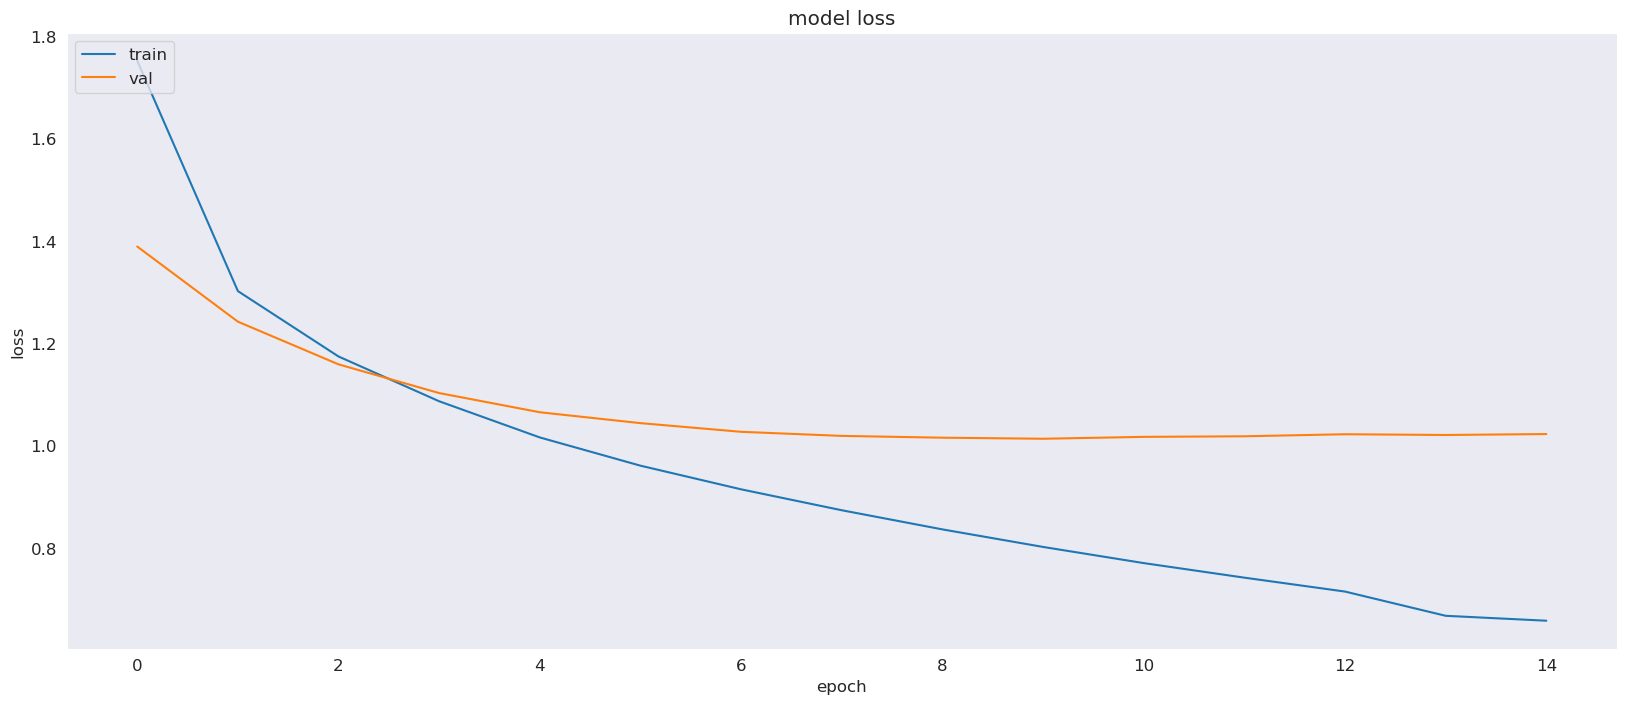

In [44]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [45]:
def idx_to_word(integer,tokenizer):
    
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None

In [64]:
def predict_caption(model, image, tokenizer, max_length, features):
    feature = features[image]
    if feature.ndim == 1:
        feature = np.expand_dims(feature, axis=0)
    feature = np.array(feature, dtype='float32')  
    
    in_text = "startseq"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        sequence = np.array(sequence, dtype='int32')  # ensure it's a NumPy array
        
        y_pred = model.predict([feature, sequence], verbose=0)
        
        token_index = len(in_text.split())
        token_probs = y_pred[0, token_index, :]
        predicted_index = np.argmax(token_probs)
        
        word = idx_to_word(predicted_index, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    return in_text


## **Taking 15 Random Samples for Caption Prediction**

In [65]:
samples = test.sample(15)
samples.reset_index(drop=True,inplace=True)

In [66]:
cnn_model = DenseNet201(include_top=False, pooling='avg', input_shape=(224, 224, 3))

for index, record in samples.iterrows():
    img_path = os.path.join(image_path, record['image'])
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img)
    img = img / 255.0
    img_batch = np.expand_dims(img, axis=0)
    
    feature = cnn_model.predict(img_batch)
    features[record['image']] = feature
    
    caption = predict_caption(caption_model, record['image'], tokenizer, max_length, features)
    samples.loc[index, 'caption'] = caption

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


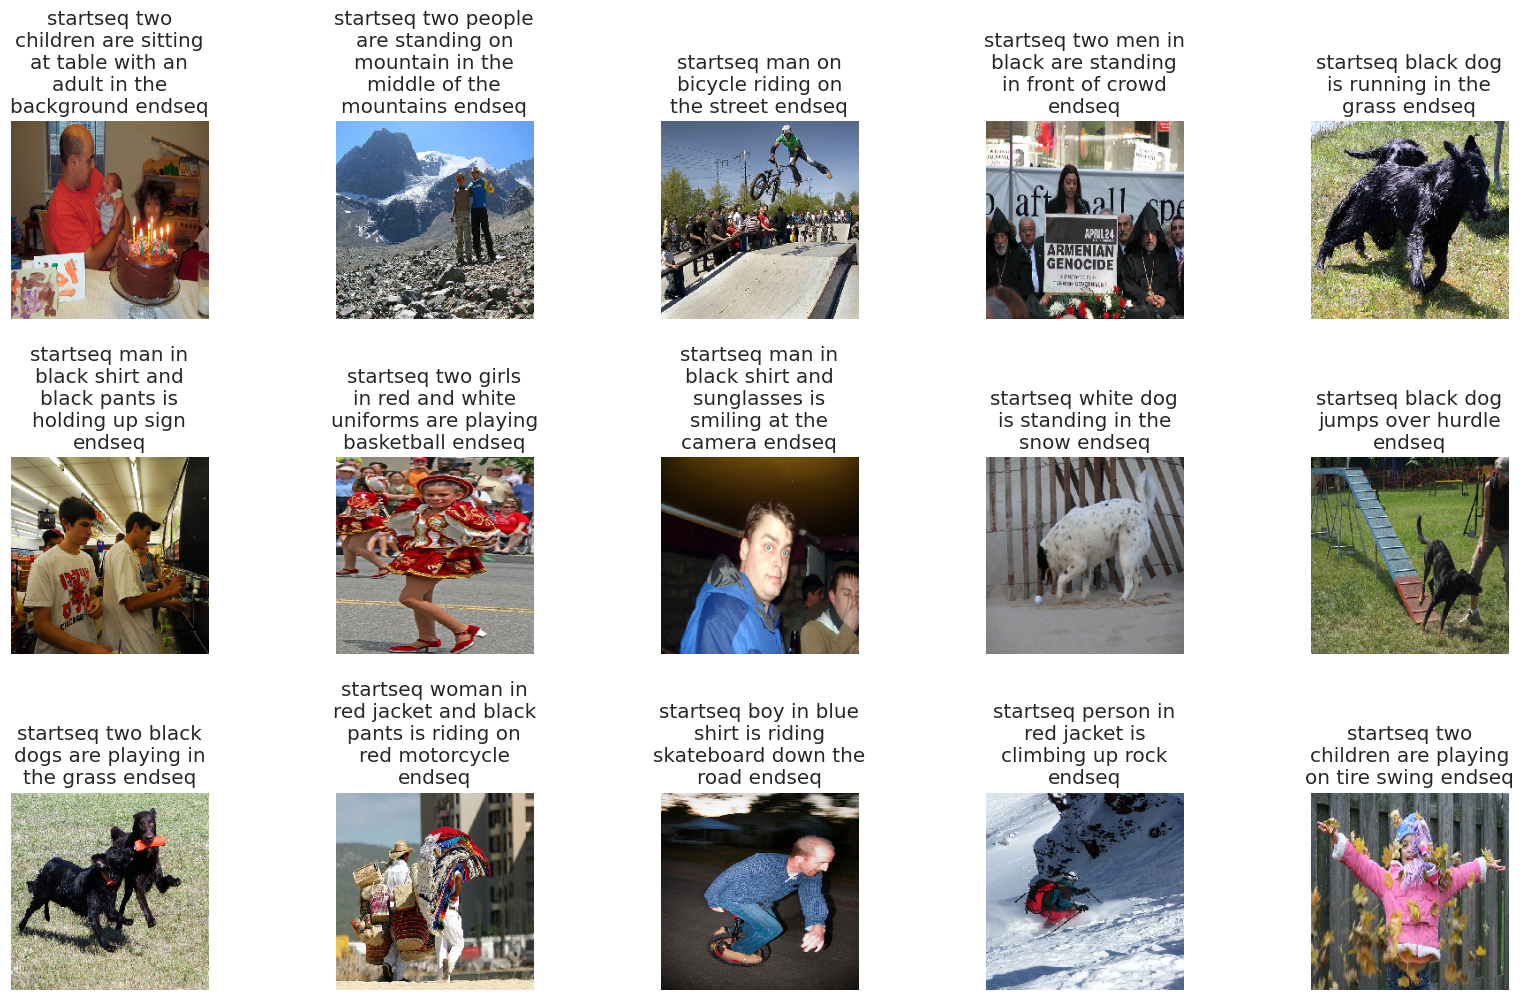

In [67]:
display_images(samples)